# 01 — Acoustic cavity modes: CHEXA8 against the closed form

**The rigid-walled air box of `Library/box_cavity.msh`, meshed with `CHEXA8`
acoustic elements: the first twelve modes compared with the analytical ones,
one by one.**

The geometry is asked for the same way as everywhere else — one dialog on
`../Library/` — but **this example accepts one file and one only**, because
what it compares against is the closed form of a rectangular box:

$$ p_{lmn} = \cos\frac{l\pi x}{L_x}\cos\frac{m\pi y}{L_y}\cos\frac{n\pi z}{L_z},
   \qquad
   f_{lmn} = \frac{c_0}{2}\sqrt{\Bigl(\frac{l}{L_x}\Bigr)^{2}
   + \Bigl(\frac{m}{L_y}\Bigr)^{2} + \Bigl(\frac{n}{L_z}\Bigr)^{2}} $$

so every computed frequency has something to be checked against. Pick
anything else in the dialog and the run **stops** in section 2, rather than
comparing a duct or a cavity with a flexible wall against modes that were
never in it.

The sides and the element counts are still **not written here**: a `.msh`
carries them, so they are read off the file as it is loaded. Rebuild that
library case at another size or another `f_max`
(`python Library/make_library.py`) and this notebook validates the new box
without a line changing.

---
## 1 — Which run, and what it is made of

The same opening as every other example: state the run and the materials
first, then ask where the geometry is.

Here the run is `"acoustic"` — the fluid alone, rigid walls, no structure.
Rigid walls need no boundary condition: $\partial p/\partial n = 0$ is the
natural one, so nothing is constrained and nothing has to be said about the
six faces.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))          # run from examples/

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import pycafe
from pycafe.core.model_spec import (
    AIR, ModelSpec, build_mesh, build_model, describe_domains,
)
from pycafe.create_geom import ask_for_geometry
from pycafe.create_geom.visualize_mesh import load_mesh_with_groups
from pycafe.post_processing.post_processing_3d import (
    extract_surface_faces, plot_pressure_3d,
)
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

# what kind of run: the fluid alone
ANALYSIS = "acoustic"

# one material per domain of that run - here there is only the one
FLUID = AIR
STRUCTURE = None

F_MAX = 1000.0        # highest frequency the mesh has to resolve [Hz]
N_MODES = 12          # modes compared with the closed form

C0 = FLUID.c0
print(f"{ANALYSIS} run up to {F_MAX:.0f} Hz, c0 = {C0:.0f} m/s")

acoustic run up to 1000 Hz, c0 = 343 m/s


---
## 2 — Where the geometry comes from, and the one file that is accepted

`ask_for_geometry()` opens the usual dialog on `../Library/` — the folder that
holds everything a run can be pointed at — and reads whatever is picked. Here
the answer has to be **`box_cavity.msh`**: the rigid air box
0.40 × 0.30 × 0.50 m, built for 1000 Hz, whose modes this notebook checks
against the formula above. Anything else stops the run on the spot.

Two ways of stopping, and both are deliberate:

* **no answer** — a cancelled dialog raises, because there is no fallback
  file anywhere in pyCAFE;
* **the wrong answer** — a duct, a cavity with a flexible wall, a CAD file:
  refused by name, before it is meshed. An example that quietly went on with
  some other geometry would still print a perfectly reasonable-looking table
  of errors against modes that were never in it.

For a run with nobody at the keyboard the dialog is answered by the
environment, `PYCAFE_FILE_GEOMETRY=../Library/box_cavity.msh`.

A `.msh` is already meshed **and** already named, so loading it is the last
question about the geometry: the roles, the selectable boundaries, the sides
of the box and the elements along each of them are all in the file, and the
cell below prints them. Nothing about the cavity is written in this
notebook.

In [2]:
CAVITY = os.path.abspath(os.path.join("..", "Library", "box_cavity.msh"))

geometry = ask_for_geometry()      # a dialog; no answer, no geometry

picked = os.path.abspath(str(getattr(geometry, "path", "")))
if picked != CAVITY:
    raise RuntimeError(
        f"this notebook validates one geometry, {os.path.basename(CAVITY)}, "
        "because that is the box the closed form below describes.\n"
        f"  picked:   {picked or geometry}\n"
        f"  expected: {CAVITY}\n"
        "Run it again and pick box_cavity.msh; every other geometry has its "
        "own notebook."
    )
print()
print(type(geometry).__name__, "->", os.path.basename(picked))

spec = ModelSpec(
    geometry=geometry,
    analysis=ANALYSIS,             # what to look for, and what to assemble
    fluid=FLUID,
    f_max=F_MAX,
    work_dir=".",
)
print()
print(spec.describe())

mesh_path, report = build_mesh(spec)    # load it, and check it against F_MAX
nodes, elements, boundaries, groups = load_mesh_with_groups(
    str(mesh_path), verbose=False
)
print()
print(report)
print(describe_domains(report, FLUID, STRUCTURE))

# The mesh is the geometry, so the box is measured on it and nothing about
# the cavity is written in this notebook.
AXES = [np.unique(np.round(nodes[:, i], 9)) for i in range(3)]
LX, LY, LZ = (a[-1] - a[0] for a in AXES)
NX, NY, NZ = (a.size - 1 for a in AXES)
print(f"  cavity: {LX:.3f} x {LY:.3f} x {LZ:.3f} m, "
      f"{NX} x {NY} x {NZ} = {NX * NY * NZ} CHEXA8, "
      f"{len(nodes)} pressure DOFs")

using /Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh
box_cavity.msh: a mesh, used as it is (its physical groups already carry the roles).

MeshFile -> box_cavity.msh

ModelSpec
  geometry     MeshFile(path=PosixPath('/Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh'), rename={}, drop=())
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  f_max        1000.0 Hz (lambda = 343 mm)
  mesh size    34.3 mm (10 elements per wavelength)
  mesh file    /Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh

/Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh  (acoustic analysis)
-----------------------------------------------------------------------------------
  2080 nodes, 846 x Quadrilateral 4, 1620 x Hexahedron 8
  roles: fluid = 'fluid'
  · fluid element size: 33.3 / 33.3 / 33.3 mm (min / mean / max)
  · good to ~1% up to 792 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 1000 Hz: 10.3 elements per wavelength, dispersion error 

---
## 3 — Picture first, then the matrices

`build_model` does the whole front end in one call: mesh, validate, **draw the
geometry coloured by role**, assemble. The picture comes before the numbers on
purpose — a cavity read in the wrong unit, or a mesh that is not the one meant,
shows up there and in none of the frequencies.

The element size was never typed: for a geometry meshed here it follows from
`F_MAX` and the ten-elements-per-wavelength rule, $h = c_0/(f_{max} n_\lambda)$;
for a mesh loaded as it stands, `F_MAX` only says what it is checked against.

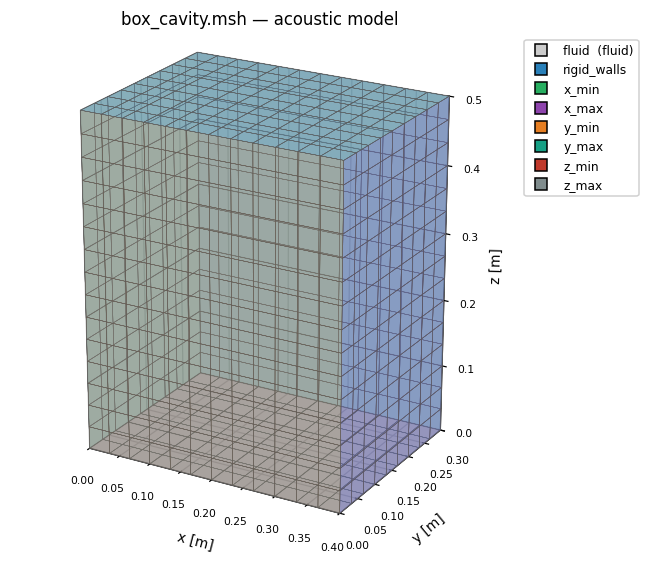

Acoustic domain from physical group 'fluid': CHEXA8
walls  : rigid (dp/dn = 0 is the natural BC - no DOF is constrained)
assembled: acoustic -> ['C', 'C_op', 'C_red', 'C_red_op', 'K', 'K_red', 'M', 'M_red', 'bc', 'bc_velocity', 'boundary_dim', 'debug', 'elem_type', 'idx_free', 'p0_nodes', 'pml_op', 'pml_red_op', 'pressure_nodes_red', 'pressure_values', 'radiation_op', 'radiation_red_op', 'source_op', 'source_red_op', 'value_velocity_normal', 'velocity_op', 'velocity_red_op']


In [3]:
model = build_model(spec)               # mesh -> validate -> draw -> assemble

nodes = model["nodes"]
system = model["system"]

print("walls  : rigid (dp/dn = 0 is the natural BC - no DOF is constrained)")
print("assembled:", model["analysis"], "->", sorted(system))

---
## 4 — Modal analysis

### 4.1 — What pyCAFE solves, and how the modes are looked at

A rigid cavity is the plain eigenproblem of the acoustic system,
$K\mathbf{p} = \omega^{2} M\mathbf{p}$, with nothing constrained: the walls
are the natural boundary condition, so `K` and `M` go into the solver as they
came out of `build_model`.

`solve_modal_acoustic_reduced` returns the frequencies in hertz and the mode
shapes as one nodal pressure per column, in ascending order. The
uniform-pressure mode $(0,0,0)$ at $f = 0$ is a genuine solution of the rigid
cavity — a constant pressure everywhere satisfies it — and the solver drops
it, so the first column that comes back is already the first real mode.

In [4]:
K, M = system["K"], system["M"]
freqs, modes = solve_modal_acoustic_reduced(K, M, num_modes=N_MODES)

print(f"{modes.shape[0]} pressure DOFs, {modes.shape[1]} modes")
print()
for i, f in enumerate(freqs):
    print(f"  mode {i+1:2d}   {f:8.2f} Hz")

2080 pressure DOFs, 12 modes

  mode  1     343.63 Hz
  mode  2     429.98 Hz
  mode  3     550.42 Hz
  mode  4     574.57 Hz
  mode  5     669.49 Hz
  mode  6     691.03 Hz
  mode  7     717.64 Hz
  mode  8     795.67 Hz
  mode  9     813.88 Hz
  mode 10     867.33 Hz
  mode 11     898.69 Hz
  mode 12     932.92 Hz


Looking at a mode means colouring the mesh by one pressure per node, and
that is what `plot_pressure_3d` does — the same renderer notebooks 02 to 04
use for their fields. Two choices make the modes readable:

* **a corner is taken out.** A closed box shows only its outer walls, and a
  mode that varies across the depth then reads as a flat slab of one colour.
  Removing one octant leaves three outer walls and opens three cuts through
  the middle, so the variation along all three axes is on the picture at
  once. `extract_surface_faces` builds that skin once and every panel reuses
  it.
* **each mode is normalised to its own peak**, with the sign fixed so that
  the peak is positive. An eigenvector is defined up to a factor: without
  that, the same mode would come out red or blue at random.

Rigid walls force a pressure antinode on every boundary, so what is left to
read off the picture is the nodal planes — the white bands — one per
half-wave in each direction.

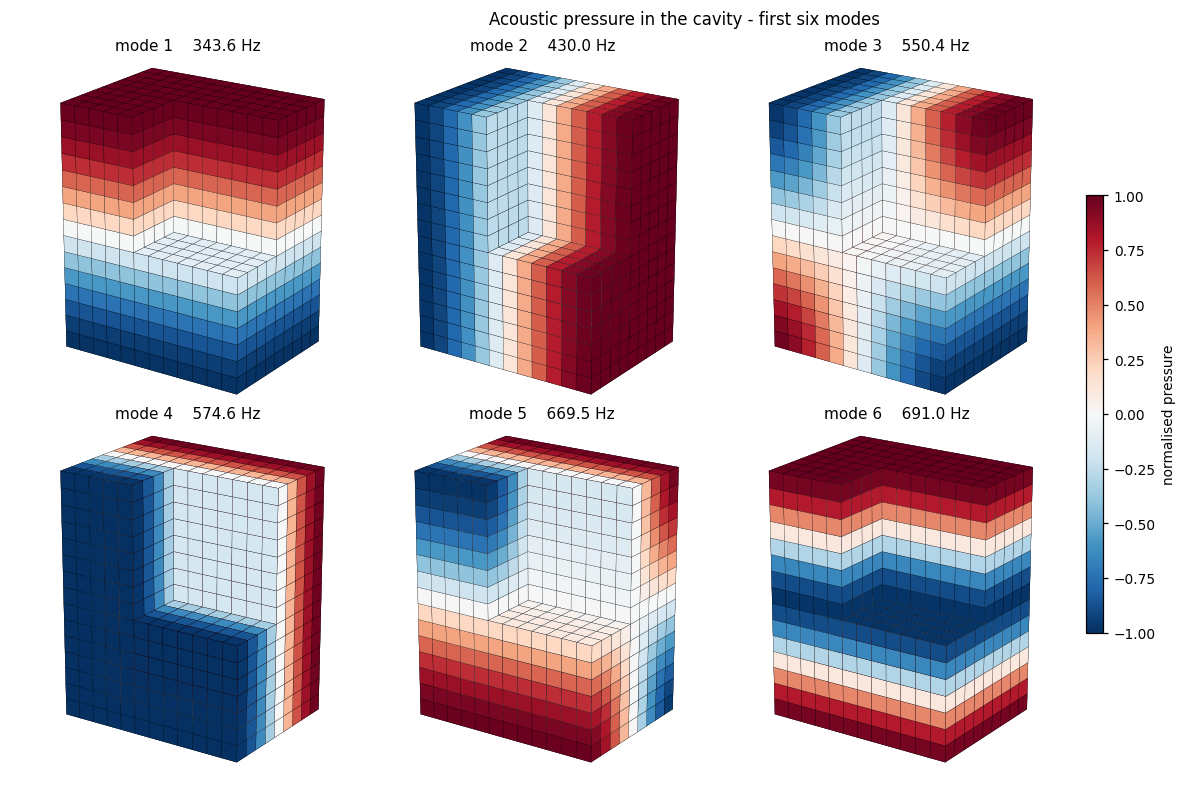

In [5]:
def cutaway_faces(nodes, elements, fraction=0.45):
    '''Skin of the mesh with the corner nearest the viewer taken out.'''
    lo, hi = nodes.min(axis=0), nodes.max(axis=0)
    corner = lo + fraction * (hi - lo)
    kept = {}
    for name, conn in elements.items():
        conn = np.asarray(conn, dtype=int)
        centre = nodes[conn - 1].mean(axis=1)
        notch = ((centre[:, 0] > corner[0]) & (centre[:, 1] < corner[1])
                 & (centre[:, 2] > corner[2]))
        kept[name] = conn[~notch]
    return extract_surface_faces(kept)


def normalise(p):
    '''A mode scaled to its peak, signed so that the peak is positive.'''
    p = p / np.abs(p).max()
    return -p if p[np.abs(p).argmax()] < 0 else p


FACES = cutaway_faces(nodes, elements)


def plot_modes(first, last, title):
    '''Modes first..last on one figure, three to a row.'''
    fig = plt.figure(figsize=(12.5, 7.2))
    for k, i in enumerate(range(first, last)):
        ax = fig.add_subplot(2, 3, k + 1, projection="3d")
        plot_pressure_3d(nodes, elements, normalise(modes[:, i]),
                         part="real", cmap="RdBu_r", clim=(-1, 1),
                         faces=FACES, ax=ax, colorbar=False,
                         elev=20, azim=-56, show=False)
        ax.set_axis_off()
        ax.set_title(f"mode {i+1}    {freqs[i]:.1f} Hz", fontsize=10, pad=-4)
    fig.suptitle(title, y=0.98)
    fig.subplots_adjust(left=0.01, right=0.93, top=0.93, bottom=0.01,
                        wspace=0.0, hspace=0.02)
    cb = fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(-1, 1),
                                        cmap="RdBu_r"),
                      ax=fig.axes, shrink=0.6, aspect=26, pad=0.01)
    cb.set_label("normalised pressure")
    plt.show()


plot_modes(0, 6, "Acoustic pressure in the cavity - first six modes")

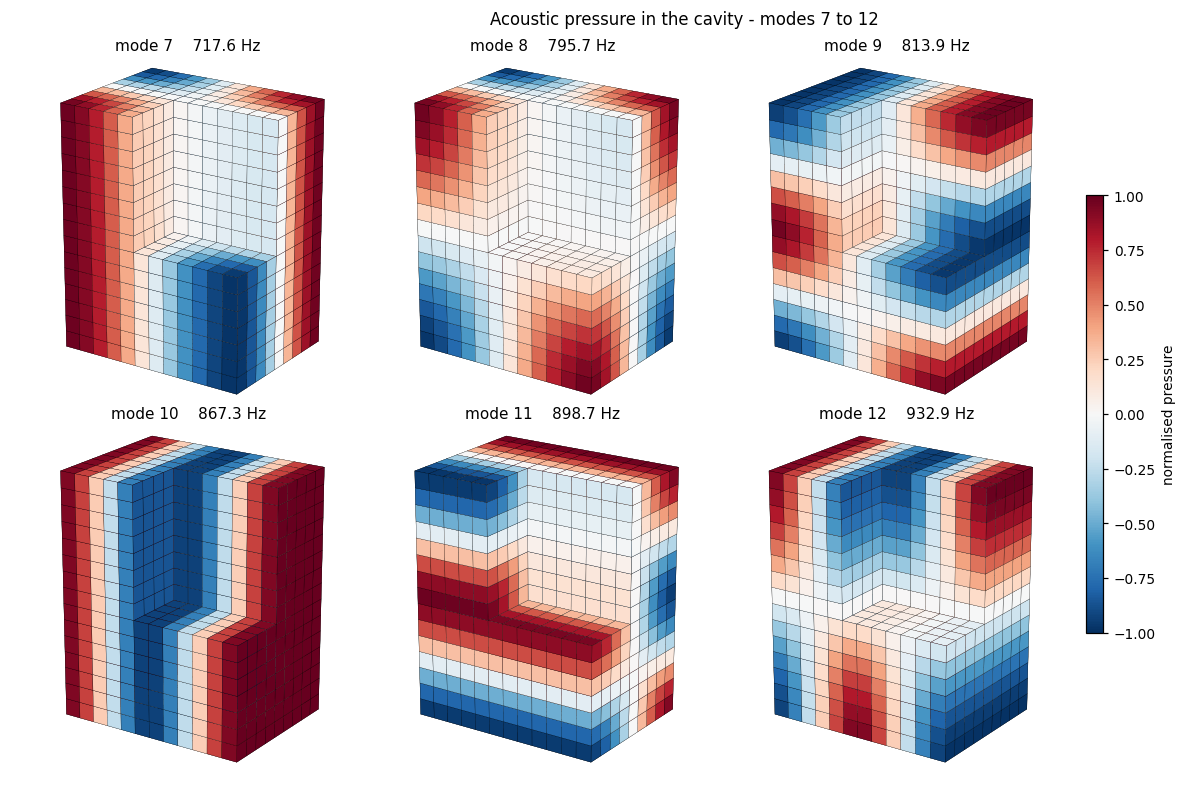

In [6]:
plot_modes(6, N_MODES,
           f"Acoustic pressure in the cavity - modes 7 to {N_MODES}")

---
### 4.2 — Against the closed form

Nothing above knows what the modes ought to be; this is where the box earns
its keep. Every computed mode is paired with the analytical shape it
correlates best with — the MAC between the two,

$$ \mathrm{MAC}(\mathbf{a}, \mathbf{p}) =
   \frac{(\mathbf{a}^{T}\mathbf{p})^{2}}
        {(\mathbf{a}^{T}\mathbf{a})(\mathbf{p}^{T}\mathbf{p})}
   \in [0, 1] $$

which is 1 for two shapes that differ by a scale factor and 0 for two that
are orthogonal. The best-correlated candidate gives the mode its $(l,m,n)$,
and that triple gives the frequency it should have had.

Pairing by shape rather than by order matters: two analytical frequencies can
sit a few hertz apart, and reading the labels off the sorted list would then
swap them and blame the solver for it. The analytical shapes are written
about the corner of the box, so the nodal coordinates are measured from the
corner the mesh turned out to have.

In [7]:
L = np.array([LX, LY, LZ])
ORIGIN = np.array([a[0] for a in AXES])          # the corner of the box
XYZ = nodes - ORIGIN

CANDIDATES = [(l, m, n) for l in range(5) for m in range(5) for n in range(5)
              if (l, m, n) != (0, 0, 0)]


def analytical_shape(idx):
    '''Nodal values of cos(l pi x/Lx) cos(m pi y/Ly) cos(n pi z/Lz).'''
    l, m, n = idx
    return (np.cos(l * np.pi * XYZ[:, 0] / LX)
            * np.cos(m * np.pi * XYZ[:, 1] / LY)
            * np.cos(n * np.pi * XYZ[:, 2] / LZ))


def mac(a, p):
    '''Modal assurance criterion between two shapes.'''
    return (a @ p) ** 2 / ((a @ a) * (p @ p))


def exact_frequency(idx):
    return C0 / 2 * np.sqrt(sum((idx[i] / L[i]) ** 2 for i in range(3)))


SHAPES = np.array([analytical_shape(idx) for idx in CANDIDATES])
labels = [CANDIDATES[int(np.argmax([mac(s, modes[:, i]) for s in SHAPES]))]
          for i in range(N_MODES)]
exact = np.array([exact_frequency(idx) for idx in labels])
error = (freqs - exact) / exact * 100

print(f"{'mode':>5s} {'(l,m,n)':>10s} {'analytical [Hz]':>17s}"
      f" {'pyCAFE [Hz]':>13s} {'error [%]':>11s}")
for i in range(N_MODES):
    print(f"{i+1:5d} {str(labels[i]):>10s} {exact[i]:17.2f}"
          f" {freqs[i]:13.2f} {error[i]:11.3f}")
print(f"\nmean error {np.abs(error).mean():.3f} % - "
      f"max error {np.abs(error).max():.3f} %")

 mode    (l,m,n)   analytical [Hz]   pyCAFE [Hz]   error [%]
    1  (0, 0, 1)            343.00        343.63       0.183
    2  (1, 0, 0)            428.75        429.98       0.286
    3  (1, 0, 1)            549.07        550.42       0.246
    4  (0, 1, 0)            571.67        574.57       0.508
    5  (0, 1, 1)            666.67        669.49       0.422
    6  (0, 0, 2)            686.00        691.03       0.733
    7  (1, 1, 0)            714.58        717.64       0.428
    8  (1, 1, 1)            792.64        795.67       0.382
    9  (1, 0, 2)            808.96        813.88       0.607
   10  (2, 0, 0)            857.50        867.33       1.146
   11  (0, 1, 2)            892.97        898.69       0.641
   12  (2, 0, 1)            923.56        932.92       1.014

mean error 0.550 % - max error 1.146 %


The table pairs each mode with one analytical shape, but says nothing about
how *safely*: a mode that correlated 0.6 with its label and 0.5 with another
would be read exactly the same way. The whole MAC matrix does say it — every
computed mode against every label — and it is worth a look precisely because
the diagonal is not the interesting part.

A diagonal of ones is what the pairing was chosen to produce. What the matrix
adds is everything off it: if those entries are near zero, each computed mode
resembles its own analytical shape and no other, and the labels in the table
are the only ones they could have had.

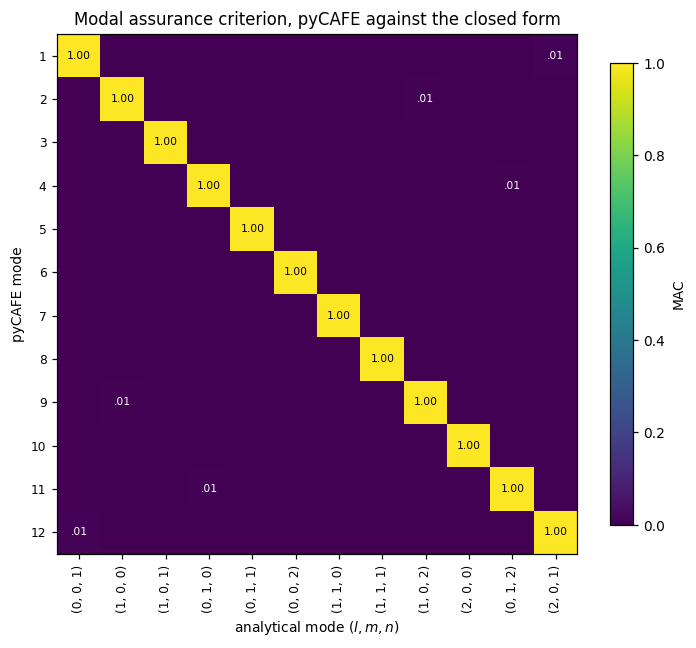

smallest MAC on the diagonal  1.0000
largest MAC off the diagonal  0.0110


In [8]:
PAIRED = np.array([analytical_shape(idx) for idx in labels])
MAC = np.array([[mac(PAIRED[j], modes[:, i]) for j in range(N_MODES)]
                for i in range(N_MODES)])

fig, ax = plt.subplots(figsize=(6.6, 5.8))
im = ax.imshow(MAC, cmap="viridis", vmin=0.0, vmax=1.0)
ax.set_xticks(range(N_MODES), [str(idx) for idx in labels],
              rotation=90, fontsize=8)
ax.set_yticks(range(N_MODES), [str(i + 1) for i in range(N_MODES)],
              fontsize=8)
ax.set_xlabel("analytical mode $(l,m,n)$")
ax.set_ylabel("pyCAFE mode")
ax.set_title("Modal assurance criterion, pyCAFE against the closed form")
for i in range(N_MODES):
    for j in range(N_MODES):
        if MAC[i, j] > 0.005:
            ax.text(j, i, f"{MAC[i, j]:.2f}".lstrip("0"), ha="center",
                    va="center", fontsize=7,
                    color="white" if MAC[i, j] < 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.85, label="MAC")
fig.tight_layout()
plt.show()

off = MAC - np.diag(np.diag(MAC))
print(f"smallest MAC on the diagonal  {np.diag(MAC).min():.4f}")
print(f"largest MAC off the diagonal  {off.max():.4f}")

---
## Summary

`Library/box_cavity.msh` — 0.40 × 0.30 × 0.50 m, 12 × 9 × 15 `CHEXA8`, 2080
pressure DOFs — gives the first twelve modes with every shape matching its
analytical $(l,m,n)$ pattern to a MAC of 1.00 against at most 0.01 with any
other, a **mean frequency error of 0.55 %** and a **maximum of 1.1 %**, on
mode 10, $(2,0,0)$.

The deviation is the numerical dispersion of a trilinear element and it is
always positive — the discretised cavity is slightly stiffer than the
continuum. It scales with the square of the mesh size, so it shrinks by a
factor of four every time the mesh is halved: rebuild the same case at twice
the `f_max` (`Library/make_library.py`) and the errors above divide by four.